In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q codecarbon thop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.6/384.6 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 124.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 120.6 MB/s eta 0:00:00


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import time

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from codecarbon import EmissionsTracker

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 160
BATCH_SIZE = 64
EPOCHS = 10
SEEDS = [42, 123, 777]

torch.set_float32_matmul_precision("high")

print("="*60)
print("Dataset              : EuroSAT")
print("Input Resolution     :", IMG_SIZE)
print("Precision            : FP32")
print("Batch Size           :", BATCH_SIZE)
print("Seeds                :", SEEDS)
print("Train/Val/Test       : 70/15/15")
print("Pretrained Weights   : ImageNet-1K")
print("="*60)

print("Using device:", DEVICE)

Dataset              : EuroSAT
Input Resolution     : 160
Precision            : FP32
Batch Size           : 64
Seeds                : [42, 123, 777]
Train/Val/Test       : 70/15/15
Pretrained Weights   : ImageNet-1K
Using device: cuda


In [6]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [7]:
transform = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [8]:
DATA_DIR = "/content/drive/MyDrive/EuroSAT_RGB/EuroSAT"

In [9]:
# ==========================================================
# EXPERIMENT DECLARATION
# ==========================================================

INPUT_SIZE = 160
BATCH_SIZE = 32

print("="*60)
print("Dataset              : EuroSAT")
print("Input Resolution     :", INPUT_SIZE)
print("Precision            : FP32")
print("Batch Size           :", BATCH_SIZE)
print("Pretrained Weights   : ImageNet")
print("Train/Val/Test Split : 70/15/15")
print("="*60)


Dataset              : EuroSAT
Input Resolution     : 160
Precision            : FP32
Batch Size           : 32
Pretrained Weights   : ImageNet
Train/Val/Test Split : 70/15/15


In [10]:
set_seed(42)

dataset = datasets.ImageFolder(
    DATA_DIR,
    transform=transform
)

train_size = int(0.70 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print("Train :", len(train_dataset))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset))
print("Classes:", dataset.classes)

Train : 18900
Val   : 4050
Test  : 4050
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nBatch Scheduling")
print("----------------")
print("Train Batch:", BATCH_SIZE)
print("Val Batch  :", BATCH_SIZE)
print("Test Batch :", BATCH_SIZE)


Batch Scheduling
----------------
Train Batch: 32
Val Batch  : 32
Test Batch : 32


In [12]:

# ==========================================================
# PRETRAINED WEIGHTS JUSTIFICATION
# ==========================================================
# ImageNet pretrained weights are used to:
# 1. Reduce training time
# 2. Reduce computational cost
# 3. Reduce energy consumption
# 4. Reduce carbon emissions
# ==========================================================

from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

def get_mobilenetv3(num_classes=10):
    weights = MobileNet_V3_Large_Weights.IMAGENET1K_V1
    model = mobilenet_v3_large(weights=weights)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # 🔓 Partial fine-tuning (last block)
    for name, param in model.named_parameters():
        if "features.15" in name or "features.16" in name:
            param.requires_grad = True

    # Replace classifier
    model.classifier[3] = nn.Linear(
        model.classifier[3].in_features,
        num_classes
    )

    return model.to(DEVICE)

In [13]:
from thop import profile

def calculate_flops():
    model = get_mobilenetv3()
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    flops, params = profile(model, inputs=(dummy,), verbose=False)
    return flops / 1e9, params / 1e6  # GFLOPs, MParams

gflops, mparams = calculate_flops()
print(f"MobileNetV3 FLOPs : {gflops:.3f} GFLOPs")
print(f"MobileNetV3 Params: {mparams:.2f} M")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 178MB/s]


MobileNetV3 FLOPs : 0.121 GFLOPs
MobileNetV3 Params: 4.21 M


In [14]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / len(loader)
    val_acc = correct / total

    return val_loss, val_acc

In [15]:
import time

def train_and_evaluate_mobilenet(seed):

    set_seed(seed)
    print(f"\n▶ Running MobileNetV3 | Seed {seed}")

    start_time = time.time()

    model = get_mobilenetv3()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=3e-4
    )

    criterion = nn.CrossEntropyLoss()

    # History containers
    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    # =========================
    # Training Loop
    # =========================
    for epoch in range(EPOCHS):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # =========================
        # Validation
        # =========================
        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] | "
            f"Train Loss={train_loss:.4f} | "
            f"Train Acc={train_acc:.4f} | "
            f"Val Loss={val_loss:.4f} | "
            f"Val Acc={val_acc:.4f}"
        )

    runtime = time.time() - start_time

    # =========================
    # Test Evaluation
    # =========================
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in test_loader:

            outputs = model(images.to(DEVICE))

            preds = torch.argmax(outputs, 1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro")
    rec = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")

    # ==========================================================
    # RUNTIME TRACKING
    # ==========================================================
    runtime = time.time() - start_time

    print(f"\nRuntime : {runtime:.2f} sec")

    return (
        acc,
        prec,
        rec,
        f1,
        runtime,
        train_losses,
        val_losses,
        train_accs,
        val_accs,
        y_true,
        y_pred
    )

In [16]:
print("\n========== DEVICE CONFIGURATION ==========")
print(f"Device : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
else:
    print("GPU : Not Available")

print("==========================================")


========== DEVICE CONFIGURATION ==========
Device : cuda
GPU : Tesla T4


[codecarbon WARNING @ 11:53:49] Multiple instances of codecarbon are allowed to run at the same time.



Running Seed: 42

▶ Running MobileNetV3 | Seed 42
Epoch [1/10] | Train Loss=0.3603 | Train Acc=0.8902 | Val Loss=0.1227 | Val Acc=0.9575
Epoch [2/10] | Train Loss=0.1394 | Train Acc=0.9528 | Val Loss=0.1009 | Val Acc=0.9647
Epoch [3/10] | Train Loss=0.0965 | Train Acc=0.9678 | Val Loss=0.1088 | Val Acc=0.9657
Epoch [4/10] | Train Loss=0.0740 | Train Acc=0.9747 | Val Loss=0.1072 | Val Acc=0.9654
Epoch [5/10] | Train Loss=0.0594 | Train Acc=0.9799 | Val Loss=0.1136 | Val Acc=0.9612
Epoch [6/10] | Train Loss=0.0427 | Train Acc=0.9861 | Val Loss=0.1153 | Val Acc=0.9677
Epoch [7/10] | Train Loss=0.0352 | Train Acc=0.9877 | Val Loss=0.1336 | Val Acc=0.9585
Epoch [8/10] | Train Loss=0.0361 | Train Acc=0.9878 | Val Loss=0.1251 | Val Acc=0.9652
Epoch [9/10] | Train Loss=0.0329 | Train Acc=0.9890 | Val Loss=0.1193 | Val Acc=0.9637
Epoch [10/10] | Train Loss=0.0266 | Train Acc=0.9909 | Val Loss=0.1170 | Val Acc=0.9659

Runtime : 11281.45 sec

Running Seed: 123

▶ Running MobileNetV3 | Seed 123
E

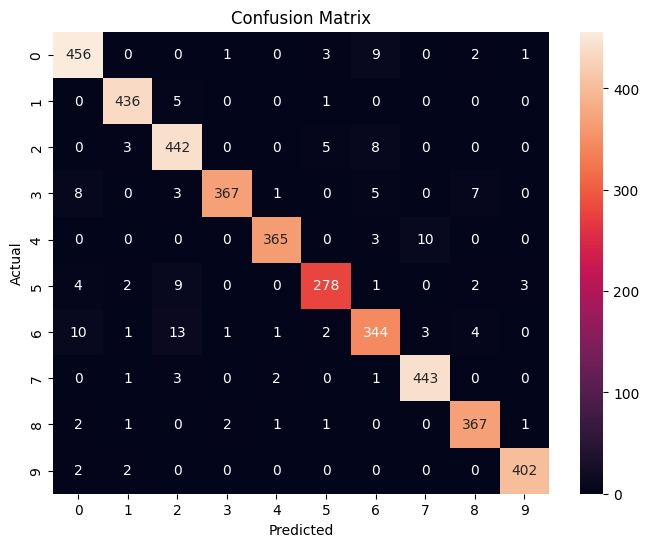

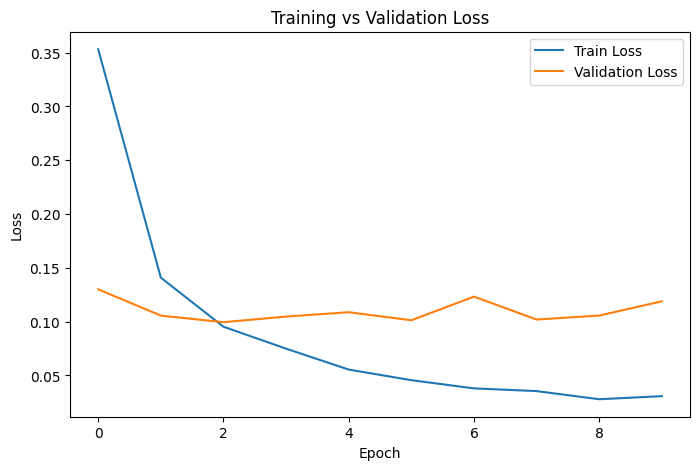

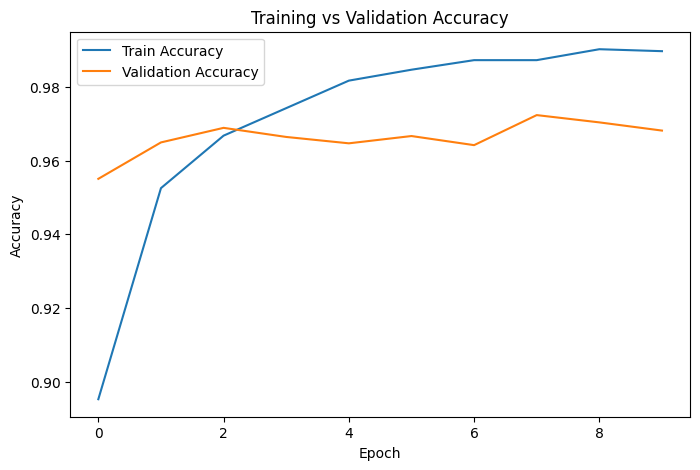


========== FINAL RESULTS ==========

Accuracy  : 0.9630 ± 0.0001
Precision : 0.9629 ± 0.0004
Recall    : 0.9617 ± 0.0005
F1 Score  : 0.9622 ± 0.0003
Runtime   : 4383.49 ± 4877.62 sec
CO2       : 0.077924 kg CO2eq


In [17]:
# ==========================================================
# MULTI-SEED EVALUATION + CO2 TRACKING
# ==========================================================

results = []

tracker = EmissionsTracker(
    project_name="MobileNetV3_GreenAI",
    tracking_mode="process",
    measure_power_secs=1,
    log_level="error"
)

tracker.start()

for seed in SEEDS:

    print(f"\nRunning Seed: {seed}")

    (
        acc,
        prec,
        rec,
        f1,
        runtime,
        train_losses,
        val_losses,
        train_accs,
        val_accs,
        y_true,
        y_pred
    ) = train_and_evaluate_mobilenet(seed)

    results.append([
        float(acc),
        float(prec),
        float(rec),
        float(f1),
        float(runtime)
    ])

# ==========================================================
# CO2 EMISSION
# ==========================================================

co2 = tracker.stop()

if co2 is None:
    co2 = 0.0

print("\n==============================")
print(f"CO2 Emission : {co2:.6f} kg CO2eq")
print("==============================")

if len(results) == 0:
    raise ValueError("No successful runs completed.")

results = np.array(results)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_true,
        y_pred,
        zero_division=0
    )
)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

print("\n========== CONFUSION MATRIX ==========\n")

import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ==========================================================
# LOSS CURVE
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

# ==========================================================
# ACCURACY CURVE
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    train_accs,
    label="Train Accuracy"
)

plt.plot(
    val_accs,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

# ==========================================================
# FINAL RESULTS
# ==========================================================

print("\n========== FINAL RESULTS ==========\n")

print(
    f"Accuracy  : {results[:,0].mean():.4f} ± {results[:,0].std():.4f}"
)

print(
    f"Precision : {results[:,1].mean():.4f} ± {results[:,1].std():.4f}"
)

print(
    f"Recall    : {results[:,2].mean():.4f} ± {results[:,2].std():.4f}"
)

print(
    f"F1 Score  : {results[:,3].mean():.4f} ± {results[:,3].std():.4f}"
)

print(
    f"Runtime   : {results[:,4].mean():.2f} ± {results[:,4].std():.2f} sec"
)

print(
    f"CO2       : {co2:.6f} kg CO2eq"
)